In [1]:
#import required classes and packages
import pandas as pd
import numpy as np
from string import punctuation
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
import pickle
from nltk.stem import PorterStemmer
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer #loading tfidf vector
from sklearn.metrics import accuracy_score
from sklearn.decomposition import LatentDirichletAllocation
import pickle
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization
from keras.layers import Convolution2D
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential, load_model, Model
from keras.callbacks import ModelCheckpoint
from keras.layers import Conv2D, MaxPool2D, Flatten, InputLayer, BatchNormalization
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
C:\Users\TruProjects\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\TruProjects\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\TruProjects\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users

In [2]:
#global variable definition to remove stop words and apply stemming and lemmatization
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

In [3]:
#define function to clean text by removing stop words and other special symbols
def cleanText(doc):
    tokens = doc.split()
    table = str.maketrans('', '', punctuation)
    tokens = [w.translate(table) for w in tokens]
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [w for w in tokens if not w in stop_words]
    tokens = [word for word in tokens if len(word) > 1]
    takens = [ps.stem(token) for token in tokens]
    takens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = ' '.join(tokens)
    return tokens

In [4]:
#load and display dataset values
dataset = pd.read_csv("Dataset/DUTA.csv", encoding="iso-8859-1")
dataset = dataset.groupby('Category').filter(lambda x: len(x) >= 1000 and len(x) < 2000)
dataset

,Vendor,Category,Item,Item_Description,Price,Origin,Destination,Rating,Remarks
1027,lonelyimage,Services/Money,List of Cardable sites,List of cardable sites for those people who wa...,0.022200487096774184 BTC,Internet,NaN,~4/5,NaN
1028,hansberger,Services/Money,Hacked Bitcoin Mining Cloudmining 1Th/s Anonymous,Hacked Bitcoin Cloud Mining 0 5BTC/Week for 2...,6.2999999999999945 BTC,NaN,NaN,[0 deals],NaN
1029,Currency,Services/Money,$20 dollars cash USD (1 x $20 bills),2/24/2014 Welcome to Cryptonaut currency serv...,0.037490000000000016 BTC,Canada,NaN,[0 deals],NaN
1030,lonelyimage,Services/Money,* Legit * Tesco Online Codes - Â£100,Tesco ONLINE CODES - Â£100 - 100% WORKING Gre...,0.14169786107142865 BTC,Internet,NaN,~4/5,NaN
1031,HellMaker,Services/Money,custom listing for 3-5k wells,custom listing for 3-5k wells,0.26207431687499994 BTC,NaN,NaN,4.43/5,NaN
...,...,...,...,...,...,...,...,...,...
109604,beige4you,Drugs/Opioids,30mg BlueBerries (Roxy/Oxycodone) x5,*****PGP ONLY!**** ****FE ONLY!***** We are ...,0.17323803 BTC,United,States,~5/5,NaN
109605,beige4you,Drugs/Opioids,1/4g (250mg) RAW UNCUT East Coast #4,*****PGP ONLY.**** ****FE ONLY.***** We are ...,0.093282015 BTC,United,States,~5/5,NaN
109606,AfghanApothecary,Drugs/Opioids,1/2 GRAM GOOD BROWN HEROIN,UK ONLY 500MG OR 1/2 GRAM BAGS OF HEROIN GOO...,0.079956015 BTC,NaN,NaN,[0 deals],NaN
109607,AfghanApothecary,Drugs/Opioids,100 MCG/HR FENTANYL PATCH,TRANSDERMAL FENTANYL PATCH HIGHEST DOSE RAPID ...,0.16657503 BTC,NaN,NaN,[0 deals],NaN


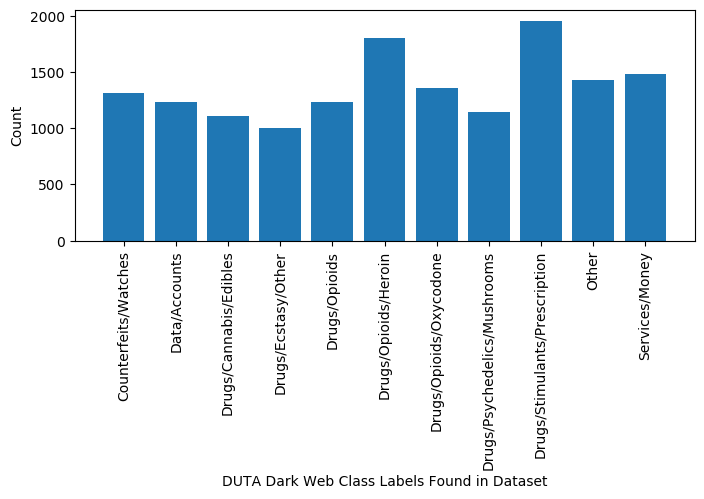

In [5]:
#read different class labels categories and description of dark web services
category = dataset['Category'].ravel()
desc = dataset['Item_Description'].ravel()
labels, count = np.unique(category, return_counts=True)
#visualizing class labels count found in dataset
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (8, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("DUTA Dark Web Class Labels Found in Dataset")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [6]:
#function to get integer class label for given service category class label
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i].strip().lower() == name.strip().lower():
            index = i
            break
    return index

In [7]:
#read each service descriton and then clean and process service text data
if os.path.exists("model/"):
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else:
    X = []
    Y = []
    for i in range(len(desc)):#load text data from dataset and then clean them
        data = desc[i]
        data = str(data)
        data = data.strip("\n").strip().lower()
        if len(data) > 100:
            data = cleanText(data)#clean text data
            X.append(data)
            label = getLabel(category[i])
            Y.append(label)
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save('model/X.txt',X)
    np.save('model/Y.txt',Y)
print("Text Cleaning Task Completed")
print("Total Drak Web Services Description found in Dataset = "+str(X.shape[0]))

Text Cleaning Task Completed
Total Drak Web Services Description found in Dataset = 12640


In [8]:
#convert Text data into TFIDF vector
#convert tweets into tfidf vector
model_path = 'model/X1.npy'

tfidf_vectorizer = TfidfVectorizer(
        stop_words=stop_words,
        use_idf=True,
        smooth_idf=False,
        norm=None,
        decode_error='replace',
        max_features=300
    )

X = tfidf_vectorizer.fit_transform(X).toarray()
    
    # Get feature names using the older method
feature_names = tfidf_vectorizer.get_feature_names()

# Check if the model directory and file exist
if os.path.exists(model_path):
    # Load the saved NumPy array
    X = np.load(model_path)
    print("Loaded pre-existing TF-IDF transformed data.")

else:
    # Initialize TfidfVectorizer with specified parameters
    tfidf_vectorizer = TfidfVectorizer(
        stop_words=stop_words,
        use_idf=True,
        smooth_idf=False,
        norm=None,
        decode_error='replace',
        max_features=300
    )
    
    # Transform data using TfidfVectorizer
    X = tfidf_vectorizer.fit_transform(X).toarray()
    
    # Get feature names using the older method
    feature_names = tfidf_vectorizer.get_feature_names()
    
    # Create DataFrame from transformed data
    data = pd.DataFrame(X, columns=feature_names)
    
    # Save the transformed data as a NumPy array
    np.save(model_path, X)
    print("Saved transformed TF-IDF data as X1.npy.")

# X now contains the transformed data
print("Transformed data shape:", X.shape)

Loaded pre-existing TF-IDF transformed data.
Transformed data shape: (12640, 300)


In [9]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("80% Text data used to train algorithms : "+str(X_train.shape[0]))
print("20% Text data used to train algorithms : "+str(X_test.shape[0]))

Dataset Train & Test Split Details
80% Text data used to train algorithms : 10112
20% Text data used to train algorithms : 2528


In [10]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [11]:
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(8, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()    

Existing KNN Accuracy  :  83.34651898734177
Existing KNN Precision : 82.45789699878637
Existing KNN Recall    : 82.44898541982386
Existing KNN FScore    : 82.27953759560819


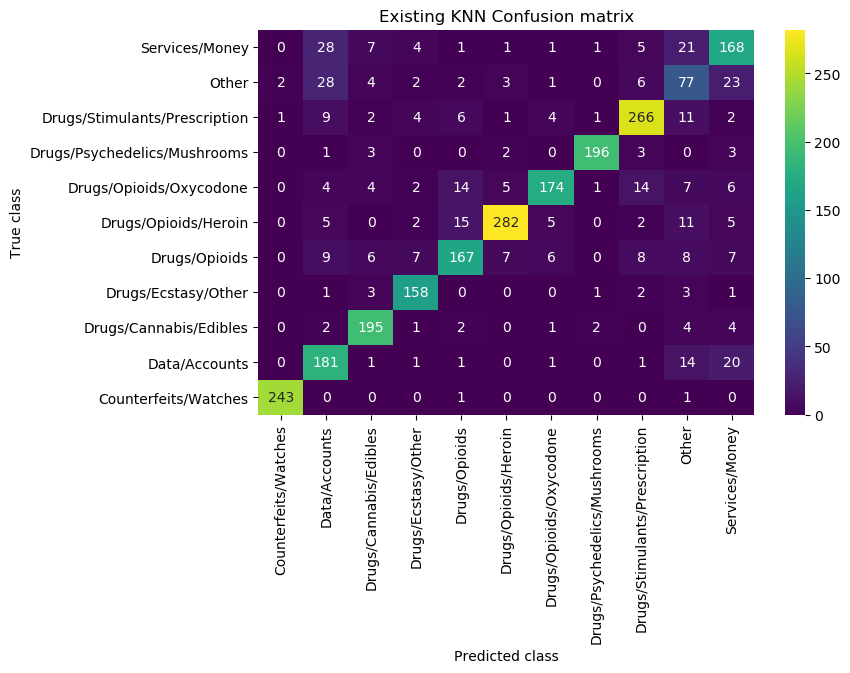

In [12]:
#train KNN algorithms using existing TF-IDF vector
knn = KNeighborsClassifier(n_neighbors=2, weights='distance')
knn.fit(X_train, y_train)
#call this function to predict on test data
predict = knn.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Existing KNN", predict, y_test)

Existing Random Forest Accuracy  :  87.30221518987342
Existing Random Forest Precision : 86.4769820514977
Existing Random Forest Recall    : 86.03639959683494
Existing Random Forest FScore    : 86.12473441034855


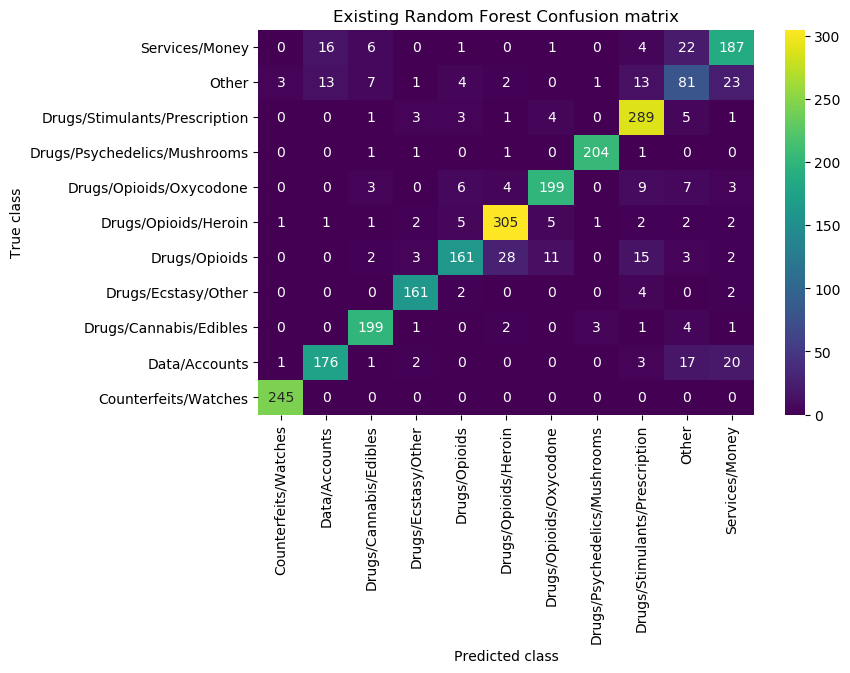

In [13]:
#train Random Forest algorithms using existing TF-IDF vector
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
#call this function to predict on test data
predict = rf.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Existing Random Forest", predict, y_test)



Propose LDA Topics with TextCNN Accuracy  :  94.6993670886076
Propose LDA Topics with TextCNN Precision : 94.23923001915281
Propose LDA Topics with TextCNN Recall    : 94.13669126029825
Propose LDA Topics with TextCNN FScore    : 94.17399220110968


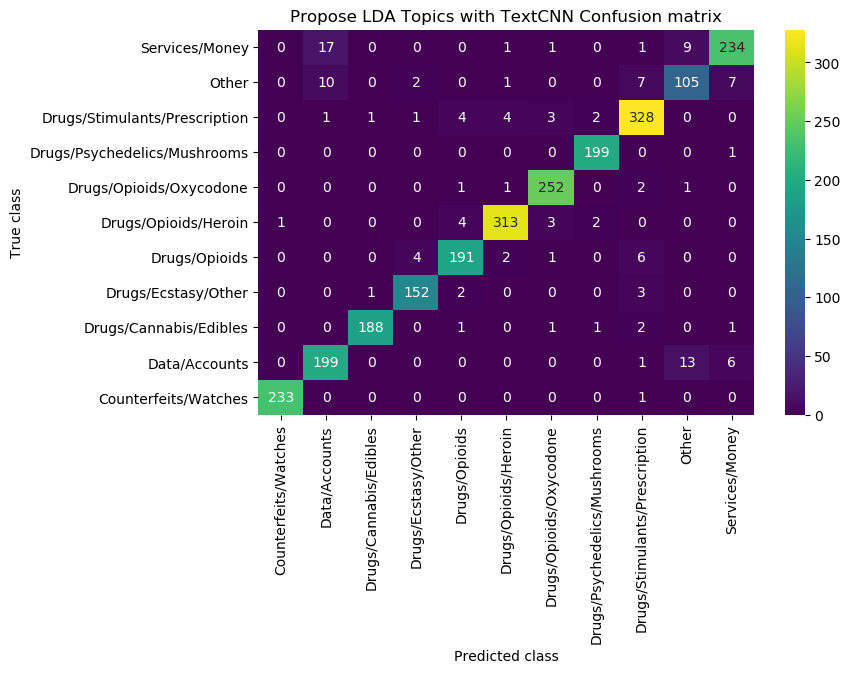

In [14]:
#to run propose algorithm we need to apply LDA algorithm to select weighted best features from TF-IDF vector
#we are selecting best 90 weighted features from LDA and then trained with propose TEXTCNN algorithm
if os.path.exists('model/lda_X_weights.txt.npy'):
    X = np.load('model/lda_X_weights.txt.npy')
    f = open('model/lda.pckl', 'rb')
    lda = pickle.load(f)
    f.close() 
else:
    #creating object of LDA and asking to select best 90% topic features
    lda = LatentDirichletAllocation(n_components=90, random_state = 42)
    lda.fit(X)
    X = lda.transform(X)#obtained best 90 features
    np.save('model/lda_X_weights.txt',X)
    f = open('model/lda.pckl', 'wb')
    pickle.dump(lda, f)
    f.close()
Y1 = to_categorical(Y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1, 1))
X_train, X_test, y_train, y_test = train_test_split(X, Y1, test_size=0.2) #split dataset into train and test
textcnn_model = Sequential() #create CNN model
#define input shape layer
textcnn_model.add(InputLayer(input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3])))
#define Conv2D layer to filter features using 25 neurons of size 5 X 5 matrix
textcnn_model.add(Conv2D(128, (5, 5), activation='relu', strides=(1, 1), padding='same'))
#max pool layer to collect filtered features and drop ir-relevant features
textcnn_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))
#another Conv2d layer for further filtration
textcnn_model.add(Conv2D(64, (5, 5), activation='relu', strides=(2, 2), padding='same'))
textcnn_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))
textcnn_model.add(BatchNormalization())
textcnn_model.add(Conv2D(32, (1, 1), activation='relu', strides=(1, 1), padding='same'))
textcnn_model.add(MaxPool2D(pool_size=(1, 1), padding='valid'))
textcnn_model.add(BatchNormalization())
textcnn_model.add(Flatten())
#output layer
textcnn_model.add(Dense(units=256, activation='relu'))
textcnn_model.add(Dense(units=256, activation='relu'))
textcnn_model.add(Dropout(0.3))
textcnn_model.add(Dense(units=y_train.shape[1], activation='softmax'))
textcnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/textcnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/textcnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = textcnn_model.fit(X_train, y_train, batch_size = 32, epochs = 30, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/textcnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    textcnn_model.load_weights("model/textcnn_weights.hdf5")
#call this function to predict on test data   
predict = textcnn_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Propose LDA Topics with TextCNN", predict, y_test1)

Extension LDA Topics with Hybrid-TextCNN Accuracy  :  96.32120253164557
Extension LDA Topics with Hybrid-TextCNN Precision : 96.04433790096928
Extension LDA Topics with Hybrid-TextCNN Recall    : 95.6750222738697
Extension LDA Topics with Hybrid-TextCNN FScore    : 95.81782292238205


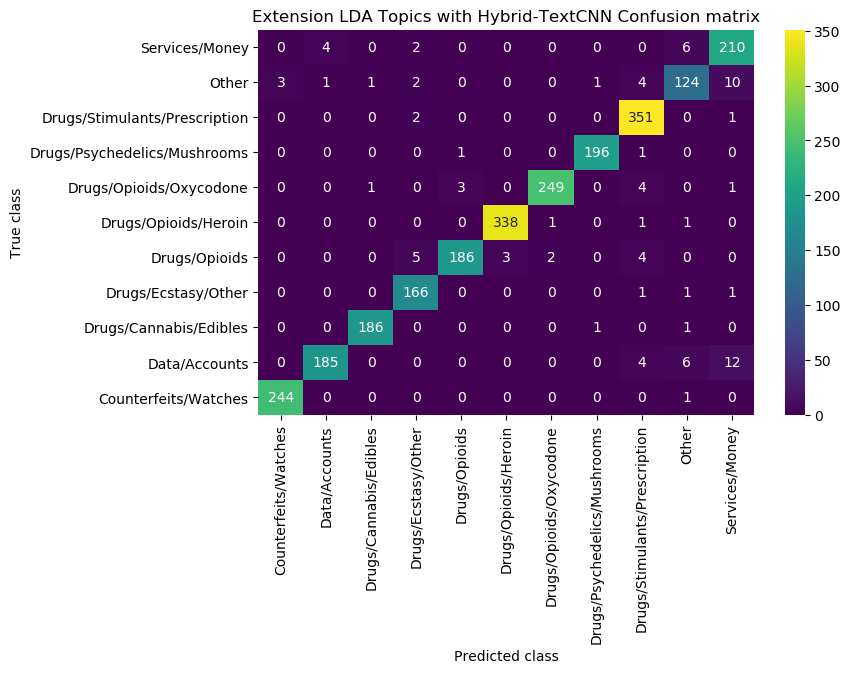

In [15]:
#train extension Hybrid-CNN model which wwill extract features from trained ANN and then retrain with CNN2D algorithm
#this extension algorithm utilize dropout layer to remove or drop ir-releevant training features
hybrid = Model(inputs = textcnn_model.inputs, outputs = textcnn_model.layers[9].output)#getting ANN model layers
features = hybrid.predict(X)#extracting hybrid features from TEXTCNN
features = np.reshape(features, (features.shape[0], features.shape[1], 1, 1))
Y1 = to_categorical(Y)
X_train, X_test, y_train, y_test = train_test_split(features, Y1, test_size=0.2) #split dataset into train and test
#training CNN2D on hybrid TEXTCNN features
extension_model = Sequential()
extension_model.add(Convolution2D(32, (1, 1), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
extension_model.add(MaxPooling2D(pool_size = (1, 1)))
extension_model.add(Dropout(0.3))
extension_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
extension_model.add(MaxPooling2D(pool_size = (1, 1)))
extension_model.add(Dropout(0.3))
extension_model.add(Flatten())
extension_model.add(Dense(units = 256, activation = 'relu'))
extension_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
extension_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/extension_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/extension_weights.hdf5', verbose = 1, save_best_only = True)
    hist = extension_model.fit(X_train, y_train, batch_size = 32, epochs = 30, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/extension_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    extension_model.load_weights("model/extension_weights.hdf5")
#call this function to predict on test data     
predict = extension_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Extension LDA Topics with Hybrid-TextCNN", predict, y_test1)

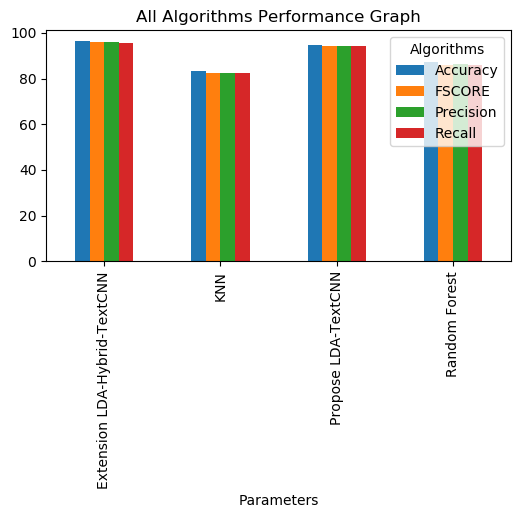

In [16]:
#plot all algorithm performance in tabukar format
import pandas as pd
df = pd.DataFrame([['KNN','Accuracy',accuracy[0]],['KNN','Precision',precision[0]],['KNN','Recall',recall[0]],['KNN','FSCORE',fscore[0]],
                   ['Random Forest','Accuracy',accuracy[1]],['Random Forest','Precision',precision[1]],['Random Forest','Recall',recall[1]],['Random Forest','FSCORE',fscore[1]],
                   ['Propose LDA-TextCNN','Accuracy',accuracy[2]],['Propose LDA-TextCNN','Precision',precision[2]],['Propose LDA-TextCNN','Recall',recall[2]],['Propose LDA-TextCNN','FSCORE',fscore[2]],
                   ['Extension LDA-Hybrid-TextCNN','Accuracy',accuracy[3]],['Extension LDA-Hybrid-TextCNN','Precision',precision[3]],['Extension LDA-Hybrid-TextCNN','Recall',recall[3]],['Extension LDA-Hybrid-TextCNN','FSCORE',fscore[3]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [17]:
#display all algorithm performnace
algorithms = ['Existing KNN', 'Existing Random Forest', 'Propose LDA-TextCNN', 'Extension LDA-Hybrid-TextCNN']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Existing KNN,83.346519,82.457897,82.448985,82.279538
1,Existing Random Forest,87.302215,86.476982,86.036400,86.124734
2,Propose LDA-TextCNN,94.699367,94.239230,94.136691,94.173992
3,Extension LDA-Hybrid-TextCNN,96.321203,96.044338,95.675022,95.817823


In [18]:
#read test data file and then predict Dark web service name
testData = pd.read_csv("Dataset/testData.csv", encoding="iso-8859-1")
desc = testData['Item_Description'].ravel()#read dark web service description
temp = []
for i in range(len(desc)):
    data = desc[i]
    data = str(data)
    data = data.strip("\n").strip().lower()
    data = cleanText(data)#clean description
    temp.append(data)
temp = tfidf_vectorizer.transform(temp).toarray()#generate TF-IDF vector
temp = lda.transform(temp)#get LDA topic modelling weight
temp = np.reshape(temp, (temp.shape[0], temp.shape[1], 1, 1))
features = hybrid.predict(temp)#extracting hybrid features from TEXTCNN
features = np.reshape(features, (features.shape[0], features.shape[1], 1, 1))
predict = extension_model.predict(features)#predict service class label from test
for i in range(len(predict)):
    y_pred = np.argmax(predict[i])
    y_pred = labels[y_pred]
    print("Dark Web Description = "+str(desc[i])+" Darkweb Classified AS ===> "+y_pred)
    print()

Dark Web Description = This elegant Channel shoulder bag is available in black  white  pink  and red.  Free shipping!! Darkweb Classified AS ===> Drugs/Opioids/Heroin

Dark Web Description = These replica Oakley Radar Lock sunglasses feature lenses that provide 100% UVA/UVB protection.  Box  sunglasses case  paperwork  and drawstring pouch included and we also provide free shipping  wo ... Darkweb Classified AS ===> Counterfeits/Watches

Dark Web Description = Need to register an account with sms verification? need sms or phone verification for something else? Contact me!  No physical products needed no burner sim no burner phone! The standard listing  ... Darkweb Classified AS ===> Services/Money

Dark Web Description = Comes with complete database to randomly choose from.  - change device ID individually and complete Mac ID.   - user friendly interface.  - A must for all Mac users supports on all Mac OS.   ... Darkweb Classified AS ===> Other

Dark Web Description = Product as pictur

In [19]:
#=================flask code starts here
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory

In [20]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [21]:
@app.route('/Predict', methods=['GET', 'POST'])
def predictView():
    return render_template('Predict.html', msg='')

@app.route('/', methods=['GET', 'POST'])
def index():
    return render_template('index.html', msg='')


@app.route('/index', methods=['GET', 'POST'])
def index1():
    return render_template('index.html', msg='')


@app.route('/AdminLogin', methods=['GET', 'POST'])
def AdminLogin():
    return render_template('AdminLogin.html', msg='')

@app.route('/AdminLoginAction', methods=['GET', 'POST'])
def AdminLoginAction():
    if request.method == 'POST' and 't1' in request.form and 't2' in request.form:
        user = request.form['t1']
        password = request.form['t2']
        if user == "admin" and password == "admin":
            return render_template('AdminScreen.html', msg="Welcome "+user)
        else:
            return render_template('AdminLogin.html', msg="Invalid login details")

@app.route('/Logout')
def Logout():
    return render_template('index.html', msg='')

def getModel():
    model = Sequential() #create CNN model
    #define input shape layer
    model.add(InputLayer(input_shape=(90, 1, 1)))
    #define Conv2D layer to filter features using 25 neurons of size 5 X 5 matrix
    model.add(Conv2D(128, (5, 5), activation='relu', strides=(1, 1), padding='same'))
    #max pool layer to collect filtered features and drop ir-relevant features
    model.add(MaxPool2D(pool_size=(2, 2), padding='same'))
    #another Conv2d layer for further filtration
    model.add(Conv2D(64, (5, 5), activation='relu', strides=(2, 2), padding='same'))
    model.add(MaxPool2D(pool_size=(2, 2), padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (1, 1), activation='relu', strides=(1, 1), padding='same'))
    model.add(MaxPool2D(pool_size=(1, 1), padding='valid'))
    model.add(BatchNormalization())
    model.add(Flatten())
    #output layer
    model.add(Dense(units=256, activation='relu'))
    model.add(Dense(units=256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(units=11, activation='softmax'))
    model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    model.load_weights("model/textcnn_weights.hdf5")
    return model

@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():
    if request.method == 'POST':
        testData = pd.read_csv("Dataset/testData.csv")#read test data
        extension_model = getModel()
        desc = testData['Item_Description'].ravel()#read dark web service description
        temp = []
        for i in range(len(desc)):
            data = desc[i]
            data = str(data)
            data = data.strip("\n").strip().lower()
            data = cleanText(data)#clean description
            temp.append(data)
        temp = tfidf_vectorizer.transform(temp).toarray()#generate TF-IDF vector
        temp = lda.transform(temp)#apply lda to select best weighted features
        temp = np.reshape(temp, (temp.shape[0], temp.shape[1], 1, 1))
        predict = extension_model.predict(temp)#predict service class label from test
        output = ""
        for i in range(len(predict)):
            y_pred = np.argmax(predict[i])
            y_pred = labels[y_pred]
            output += "Dark Web Description = "+str(desc[i])+" Darkweb Classified AS ===> "+y_pred+"<br/><br/>" 
        return render_template('AdminScreen.html', msg=output)

In [ ]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__' (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
